<a href="https://colab.research.google.com/github/pawarsakshi966-dot/Machine_Learning/blob/main/feature_scaling_standardization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
df=pd.read_csv('Social_Network_Adss.csv')
df


,Age,EstimatedSalary,Purchased
0,56,115235,1
1,46,89740,1
2,32,131352,0
3,60,81617,1
4,25,31896,0
...,...,...,...
395,43,68441,0
396,54,15846,0
397,43,25954,0
398,40,94239,0


**Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('Purchased', axis=1),
    df['Purchased'],
    test_size=0.3,
    random_state=0
)

X_train.shape, X_test.shape

((280, 2), (120, 2))

**StandardScalar**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
scaler.mean_

array([3.93714286e+01, 8.16638071e+04])

In [ ]:
X_train

,Age,EstimatedSalary
92,52,59811
223,49,35309
234,42,113142
232,28,15404
377,50,18812
...,...,...
323,50,110257
192,18,117023
117,31,104780
47,24,106680


In [ ]:
X_train_scaled

,Age,EstimatedSalary
0,1.015858,-0.546140
1,0.774534,-1.158487
2,0.211446,0.786695
3,-0.914732,-1.655948
4,0.854975,-1.570776
...,...,...
275,0.854975,0.714593
276,-1.719144,0.883688
277,-0.673408,0.577714
278,-1.236497,0.625198


In [ ]:

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)


In [ ]:
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,39.4,81663.8
std,12.5,40084.9
min,18.0,15404.0
25%,29.0,42584.8
50%,41.0,83949.5
75%,50.0,117866.5
max,60.0,149668.0


In [ ]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.7,-1.7
25%,-0.8,-1.0
50%,0.1,0.1
75%,0.9,0.9
max,1.7,1.7


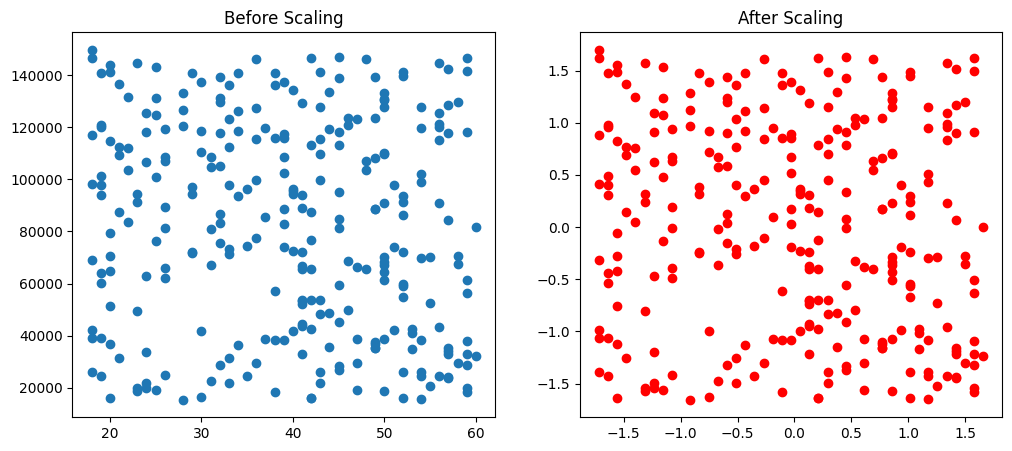

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")

ax2.scatter(
    X_train_scaled['Age'],
    X_train_scaled['EstimatedSalary'],
    color='red'
)
ax2.set_title("After Scaling")

plt.show()

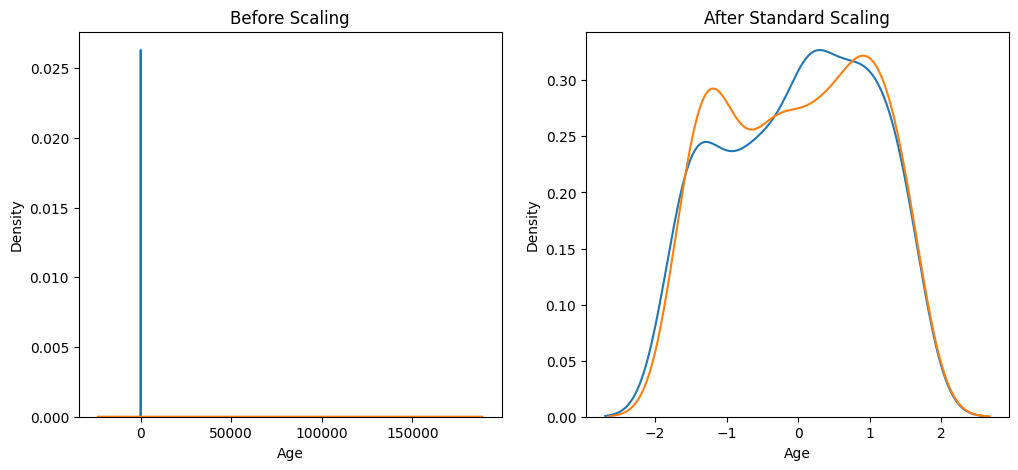

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)

plt.show()

**comparison of distribution**